In [ ]:
from google.colab import files as colab_files
import os, json, shutil

for fname in ["train.json", "val.json", "test.json"]:
    for path in [f"/content/{fname}",
                 f"/content/{fname.replace('.json', ' (1).json')}",
                 f"/content/{fname.replace('.json', ' (2).json')}"]:
        if os.path.exists(path):
            os.remove(path)
            print(f"Removed stale: {path}")

print("Upload train.json, val.json, test.json — select all 3 at once")
uploaded = colab_files.upload()

for fname in ["train.json", "val.json", "test.json"]:
    match = None
    for key in uploaded:
        if fname.replace(".json", "") in key:
            match = key
            break
    if match is None:
        print(f"ERROR: could not find {fname} in uploaded files")
        print(f"  Uploaded keys: {list(uploaded.keys())}")
    else:
        with open(f"/content/{fname}", "wb") as f:
            f.write(uploaded[match])
        size = os.path.getsize(f"/content/{fname}")
        data = json.loads(uploaded[match])
        print(f"  {fname}: {len(data)} records, {size} bytes  ✓")

SAVE_DIR = "/content/p3_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"\nReady. SAVE_DIR={SAVE_DIR}")

Upload train.json, val.json, test.json — select all 3 at once


Saving test.json to test.json
Saving train.json to train.json
Saving val.json to val.json
  train.json: 700 records, 3667160 bytes  ✓
  val.json: 150 records, 839521 bytes  ✓
  test.json: 150 records, 793364 bytes  ✓

Ready. SAVE_DIR=/content/p3_outputs


In [ ]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'scikit-learn'], check=True)

import math, string, time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

VOCAB      = list(string.ascii_lowercase + string.digits) + ['<PAD>', '<UNK>']
C2I        = {c: i for i, c in enumerate(VOCAB)}
VOCAB_SIZE = len(VOCAB)   # 38
PAD_IDX    = C2I['<PAD>'] # 36
MAX_LEN    = 512
KEY        = "CIPHER"
KEY_LEN    = len(KEY)     # 6
print("Constants ready.")

Device: cuda
Constants ready.


In [ ]:
def encode(text):
    ids = [C2I.get(c, C2I['<UNK>']) for c in text[:MAX_LEN]]
    ids += [PAD_IDX] * (MAX_LEN - len(ids))
    return torch.tensor(ids, dtype=torch.long)

def get_padding_mask(x):
    return x == PAD_IDX

class CipherDataset(Dataset):
    def __init__(self, split):
        path = f"/content/{split}.json"
        with open(path, encoding="utf-8") as f:
            records = json.load(f)
        self.pairs = []
        for r in records:
            enc   = ''.join(c for c in r['ciphertext'].lower() if c in C2I)
            plain = ''.join(c for c in r['plaintext'].lower()  if c in C2I)
            if len(enc) < 50 or len(plain) < 50:
                continue
            self.pairs.append((encode(enc), encode(plain)))
        print(f"  {split}: {len(self.pairs)} pairs")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        return self.pairs[i]

train_loader = DataLoader(CipherDataset("train"), batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(CipherDataset("val"),   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(CipherDataset("test"),  batch_size=32, shuffle=False, num_workers=2)
print("Data ready.")

  train: 700 pairs
  val: 150 pairs
  test: 150 pairs
Data ready.


In [ ]:
class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class NoPE(nn.Module):
    def __init__(self, d_model, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(x)


class LearnedPE(nn.Module):
    def __init__(self, d_model, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.pe      = nn.Embedding(max_len, d_model)
        nn.init.normal_(self.pe.weight, std=0.02)

    def forward(self, x):
        B, T, _ = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        return self.dropout(x + self.pe(pos))


class RoPE(nn.Module):
    def __init__(self, d_model, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        inv_freq = 1.0 / (
            10000 ** (torch.arange(0, d_model, 2).float() / d_model)
        )
        self.register_buffer('inv_freq', inv_freq)

    def forward(self, x):
        B, T, D = x.shape
        t      = torch.arange(T, device=x.device).float()
        freqs  = torch.outer(t, self.inv_freq)
        cos_   = freqs.cos().unsqueeze(0)
        sin_   = freqs.sin().unsqueeze(0)
        x1, x2 = x[..., 0::2], x[..., 1::2]
        x_rot   = torch.cat(
            [x1 * cos_ - x2 * sin_, x1 * sin_ + x2 * cos_], dim=-1
        )
        return self.dropout(x_rot)


class ModularPE(nn.Module):

    def __init__(self, d_model, key_len=KEY_LEN, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        for t in range(max_len):
            phase = 2 * math.pi * (t % key_len) / key_len
            for d in range(0, d_model, 2):
                harmonic   = (d // 2) + 1
                pe[t, d]   = math.sin(harmonic * phase)
                if d + 1 < d_model:
                    pe[t, d + 1] = math.cos(harmonic * phase)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


PE_CLASSES = {
    "sinusoidal" : SinusoidalPE,
    "none"       : NoPE,
    "learned"    : LearnedPE,
    "rope"       : RoPE,
    "modular"    : ModularPE,
}
print("All 5 PE classes defined:", list(PE_CLASSES.keys()))

All 5 PE classes defined: ['sinusoidal', 'none', 'learned', 'rope', 'modular']


In [ ]:
class TransformerLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_ff, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(
            d_model, nhead, dropout=dropout, batch_first=True
        )
        self.ff    = nn.Sequential(
            nn.Linear(d_model, dim_ff), nn.ReLU(), nn.Linear(dim_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        out, _ = self.attn(
            x, x, x, key_padding_mask=key_padding_mask, need_weights=False
        )
        x = self.norm1(x + self.drop(out))
        x = self.norm2(x + self.drop(self.ff(x)))
        return x


class PETransformer(nn.Module):

    def __init__(self, pe_type="sinusoidal", vocab_size=VOCAB_SIZE,
                 d_model=256, nhead=8, num_layers=4, dim_ff=1024, dropout=0.1):
        super().__init__()
        self.embed  = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pe     = PE_CLASSES[pe_type](d_model, dropout=dropout)
        self.layers = nn.ModuleList([
            TransformerLayer(d_model, nhead, dim_ff, dropout)
            for _ in range(num_layers)
        ])
        self.proj  = nn.Linear(d_model, vocab_size)
        self.scale = math.sqrt(d_model)

    def forward(self, x, key_padding_mask=None):
        x = self.pe(self.embed(x) * self.scale)
        for layer in self.layers:
            x = layer(x, key_padding_mask=key_padding_mask)
        return self.proj(x)


class LSTMDecryptor(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=128,
                 hidden=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm  = nn.LSTM(
            embed_dim, hidden, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.proj          = nn.Linear(hidden * 2, vocab_size)
        self.stored_hidden = None

    def forward(self, x):
        out, _             = self.lstm(self.embed(x))
        self.stored_hidden = out.detach().cpu()
        return self.proj(out)

print("Models defined.")

Models defined.


In [ ]:
CRITERION = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

def train_epoch(model, loader, optimizer, is_tf):
    model.train()
    total = 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()
        out = (model(src, key_padding_mask=get_padding_mask(src))
               if is_tf else model(src))
        loss = CRITERION(out.reshape(-1, VOCAB_SIZE), tgt.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def evaluate(model, loader, is_tf):
    model.eval()
    correct = total = loss_sum = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            out = (model(src, key_padding_mask=get_padding_mask(src))
                   if is_tf else model(src))
            loss_sum += CRITERION(
                out.reshape(-1, VOCAB_SIZE), tgt.reshape(-1)
            ).item()
            pred     = out.argmax(-1)
            mask     = tgt != PAD_IDX
            correct += (pred[mask] == tgt[mask]).sum().item()
            total   += mask.sum().item()
    return loss_sum / len(loader), correct / total

def run_training(name, model, is_tf, epochs=30):
    model   = model.to(DEVICE)
    opt     = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_val_loss = float('inf')
    best_char_acc = 0.0
    history       = []

    for epoch in range(1, epochs + 1):
        train_epoch(model, train_loader, opt, is_tf)
        val_loss, val_acc = evaluate(model, val_loader, is_tf)
        sched.step()
        history.append(round(val_acc * 100, 2))
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_char_acc = val_acc * 100
            torch.save(model.state_dict(),
                       os.path.join(SAVE_DIR, f"{name}.pt"))
        if epoch % 5 == 0:
            print(f"  [{name}] Epoch {epoch:2d}  val_acc={val_acc*100:.2f}%")

    model.load_state_dict(
        torch.load(os.path.join(SAVE_DIR, f"{name}.pt"), map_location=DEVICE)
    )
    _, test_acc = evaluate(model, test_loader, is_tf)
    print(f"  [{name}] DONE  best_val={best_char_acc:.2f}%  test={test_acc*100:.2f}%")
    return model, best_char_acc, test_acc * 100, history

print("Training helpers ready.")

Training helpers ready.


In [ ]:
RESULTS_PATH = os.path.join(SAVE_DIR, "p3_results.json")
PE_ORDER     = ["sinusoidal", "none", "learned", "rope", "modular"]

if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        all_results = json.load(f)
    print(f"Resuming — {len(all_results)} conditions already done.")
else:
    all_results = {}

trained_models = {}

for pe_type in PE_ORDER:
    if pe_type in all_results:
        print(f"Skipping {pe_type} — test={all_results[pe_type]['test_acc']:.2f}%")
        m  = PETransformer(pe_type=pe_type).to(DEVICE)
        pt = os.path.join(SAVE_DIR, f"tf_{pe_type}.pt")
        if os.path.exists(pt):
            m.load_state_dict(torch.load(pt, map_location=DEVICE))
        trained_models[pe_type] = m
        continue

    print(f"\n{'='*55}")
    print(f"  Transformer  PE: {pe_type.upper()}")
    print(f"{'='*55}")
    m, best_val, test_acc, history = run_training(
        f"tf_{pe_type}", PETransformer(pe_type=pe_type), is_tf=True, epochs=30
    )
    trained_models[pe_type] = m
    all_results[pe_type] = {
        "best_val_acc" : round(best_val,  2),
        "test_acc"     : round(test_acc,  2),
        "history"      : history,
    }
    with open(RESULTS_PATH, "w") as f:
        json.dump(all_results, f, indent=2)

if "lstm" not in all_results:
    print(f"\n{'='*55}")
    print("  LSTM reference")
    print(f"{'='*55}")
    lstm_m, best_val, test_acc, history = run_training(
        "lstm_ref", LSTMDecryptor(), is_tf=False, epochs=50
    )
    trained_models["lstm"] = lstm_m
    all_results["lstm"] = {
        "best_val_acc" : round(best_val, 2),
        "test_acc"     : round(test_acc, 2),
        "history"      : history,
    }
    with open(RESULTS_PATH, "w") as f:
        json.dump(all_results, f, indent=2)
else:
    print(f"\nLSTM done — test={all_results['lstm']['test_acc']:.2f}%")
    lstm_m = LSTMDecryptor().to(DEVICE)
    pt = os.path.join(SAVE_DIR, "lstm_ref.pt")
    if os.path.exists(pt):
        lstm_m.load_state_dict(torch.load(pt, map_location=DEVICE))
    trained_models["lstm"] = lstm_m

print("\nAll training complete.")


  Transformer  PE: SINUSOIDAL
  [tf_sinusoidal] Epoch  5  val_acc=38.51%
  [tf_sinusoidal] Epoch 10  val_acc=37.65%
  [tf_sinusoidal] Epoch 15  val_acc=38.52%
  [tf_sinusoidal] Epoch 20  val_acc=39.10%
  [tf_sinusoidal] Epoch 25  val_acc=39.26%
  [tf_sinusoidal] Epoch 30  val_acc=39.35%
  [tf_sinusoidal] DONE  best_val=39.35%  test=39.19%

  Transformer  PE: NONE
  [tf_none] Epoch  5  val_acc=39.05%
  [tf_none] Epoch 10  val_acc=38.28%
  [tf_none] Epoch 15  val_acc=38.88%
  [tf_none] Epoch 20  val_acc=39.15%
  [tf_none] Epoch 25  val_acc=39.36%
  [tf_none] Epoch 30  val_acc=39.39%
  [tf_none] DONE  best_val=39.39%  test=39.15%

  Transformer  PE: LEARNED
  [tf_learned] Epoch  5  val_acc=38.35%
  [tf_learned] Epoch 10  val_acc=38.79%
  [tf_learned] Epoch 15  val_acc=39.26%
  [tf_learned] Epoch 20  val_acc=39.05%
  [tf_learned] Epoch 25  val_acc=39.17%
  [tf_learned] Epoch 30  val_acc=39.40%
  [tf_learned] DONE  best_val=39.40%  test=39.22%

  Transformer  PE: ROPE
  [tf_rope] Epoch  5 

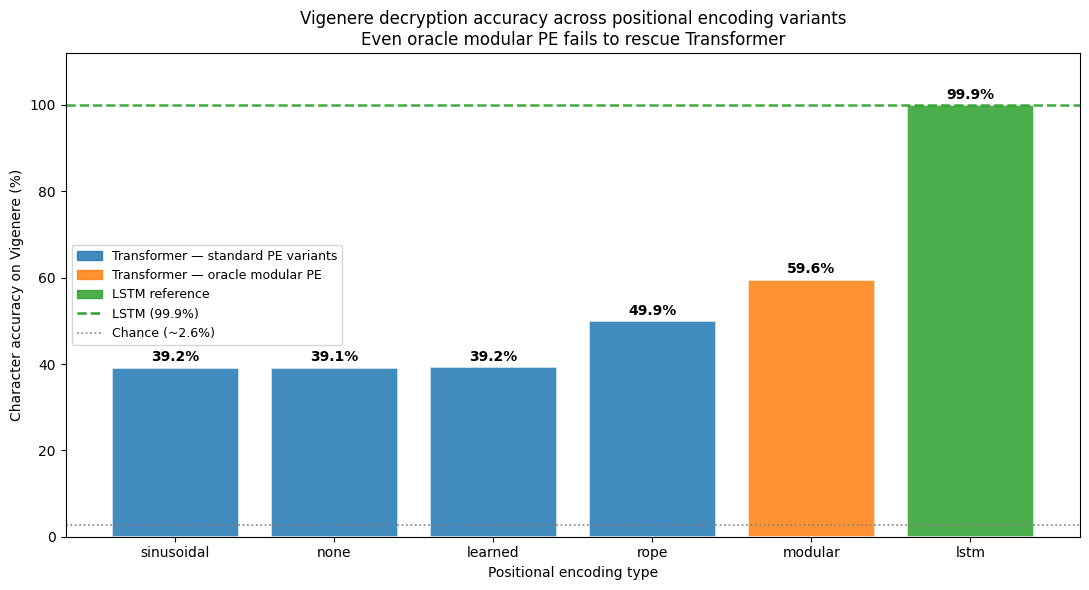

Saved: fig_p3_pe_comparison.pdf


In [ ]:
with open(RESULTS_PATH) as f:
    all_results = json.load(f)

lstm_acc = all_results["lstm"]["test_acc"]
PE_ORDER = ["sinusoidal", "none", "learned", "rope", "modular"]
labels   = [k for k in PE_ORDER + ["lstm"] if k in all_results]
accs     = [all_results[k]["test_acc"] for k in labels]

bar_colors = []
for k in labels:
    if k == "lstm":      bar_colors.append("#2ca02c")
    elif k == "modular": bar_colors.append("#ff7f0e")
    else:                bar_colors.append("#1f77b4")

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(labels, accs, color=bar_colors, alpha=0.85,
              edgecolor="white", linewidth=1.2)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f"{acc:.1f}%", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.axhline(lstm_acc, color="#2ca02c", linestyle="--",
           linewidth=1.8, alpha=0.9)
ax.axhline(2.6, color="gray", linestyle=":", linewidth=1.2)

ax.legend(handles=[
    mpatches.Patch(color="#1f77b4", alpha=0.85,
                   label="Transformer — standard PE variants"),
    mpatches.Patch(color="#ff7f0e", alpha=0.85,
                   label="Transformer — oracle modular PE"),
    mpatches.Patch(color="#2ca02c", alpha=0.85,
                   label="LSTM reference"),
    plt.Line2D([0],[0], color="#2ca02c", linestyle="--",
               linewidth=1.8, label=f"LSTM ({lstm_acc:.1f}%)"),
    plt.Line2D([0],[0], color="gray", linestyle=":",
               linewidth=1.2, label="Chance (~2.6%)"),
], fontsize=9)

ax.set_xlabel("Positional encoding type")
ax.set_ylabel("Character accuracy on Vigenere (%)")
ax.set_ylim(0, 112)
ax.set_title(
    "Vigenere decryption accuracy across positional encoding variants\n"
    "Even oracle modular PE fails to rescue Transformer"
)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "fig_p3_pe_comparison.pdf"))
plt.show()
print("Saved: fig_p3_pe_comparison.pdf")

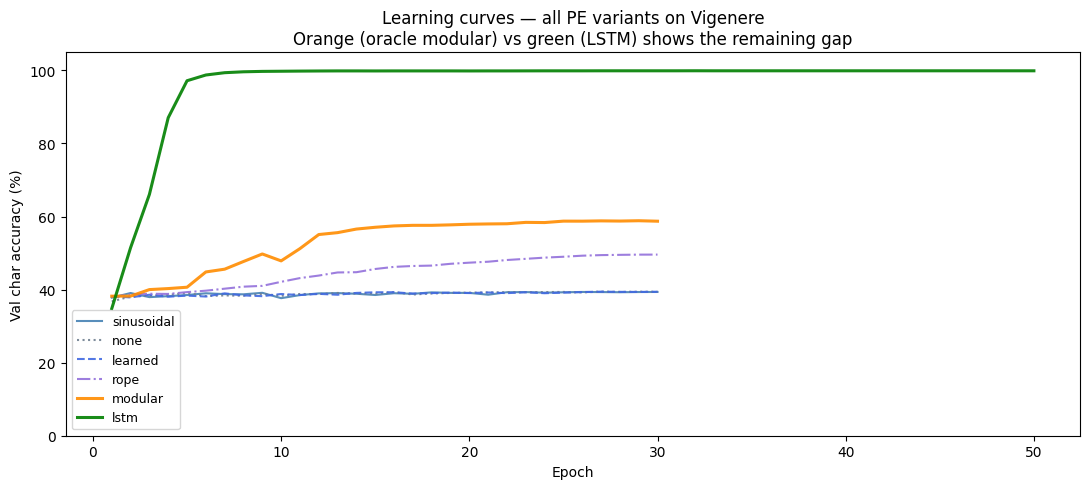

Saved: fig_p3_learning_curves.pdf


In [ ]:
with open(RESULTS_PATH) as f:
    all_results = json.load(f)

colors_map = {
    "sinusoidal" : "steelblue",
    "none"       : "slategray",
    "learned"    : "royalblue",
    "rope"       : "mediumpurple",
    "modular"    : "darkorange",
    "lstm"       : "green",
}
ls_map = {
    "sinusoidal" : "-",
    "none"       : ":",
    "learned"    : "--",
    "rope"       : "-.",
    "modular"    : "-",
    "lstm"       : "-",
}

fig, ax = plt.subplots(figsize=(11, 5))
for pe in PE_ORDER + ["lstm"]:
    if pe not in all_results:
        continue
    hist = all_results[pe]["history"]
    ax.plot(range(1, len(hist) + 1), hist,
            color=colors_map[pe], linestyle=ls_map[pe],
            linewidth=2.2 if pe in ["modular", "lstm"] else 1.5,
            label=pe, alpha=0.9)

ax.set_xlabel("Epoch")
ax.set_ylabel("Val char accuracy (%)")
ax.set_ylim(0, 105)
ax.set_title(
    "Learning curves — all PE variants on Vigenere\n"
    "Orange (oracle modular) vs green (LSTM) shows the remaining gap"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "fig_p3_learning_curves.pdf"))
plt.show()
print("Saved: fig_p3_learning_curves.pdf")

In [ ]:
def extract_hidden_tf(model, loader, n_batches=15):
    alpha_ids  = set(C2I[c] for c in string.ascii_lowercase)
    all_h, all_labels = [], []
    for i, (src, tgt) in enumerate(loader):
        if i >= n_batches:
            break
        src_cpu  = src.clone()
        src      = src.to(DEVICE)
        captured = []
        handle   = model.layers[-1].register_forward_hook(
            lambda m, inp, out: captured.append(out.detach().cpu())
        )
        with torch.no_grad():
            model(src, key_padding_mask=get_padding_mask(src))
        handle.remove()

        hidden   = captured[0]
        B, T, D  = hidden.shape
        labels   = np.full((B, T), -1, dtype=int)
        for b in range(B):
            ki = 0
            for t in range(T):
                if src_cpu[b, t].item() in alpha_ids:
                    labels[b, t] = ki % KEY_LEN
                    ki += 1

        h_flat = hidden.reshape(-1, D).numpy()
        l_flat = labels.reshape(-1)
        valid  = l_flat >= 0
        all_h.append(h_flat[valid])
        all_labels.append(l_flat[valid])

    return np.concatenate(all_h), np.concatenate(all_labels)

def run_probe(X, y):
    split    = int(0.8 * len(X))
    scaler   = StandardScaler()
    X_tr     = scaler.fit_transform(X[:split])
    X_te     = scaler.transform(X[split:])
    clf      = LogisticRegression(max_iter=1000, C=1.0)
    clf.fit(X_tr, y[:split])
    return accuracy_score(y[split:], clf.predict(X_te)) * 100

print("Running linear probes (cycle phase decodability)...")
print(f"Chance = {100/KEY_LEN:.1f}%  (6-class)\n")

probe_results = {}
for pe_type in ["sinusoidal", "modular"]:
    if pe_type not in trained_models:
        m  = PETransformer(pe_type=pe_type).to(DEVICE)
        pt = os.path.join(SAVE_DIR, f"tf_{pe_type}.pt")
        m.load_state_dict(torch.load(pt, map_location=DEVICE))
        trained_models[pe_type] = m
    trained_models[pe_type].eval()
    X, y = extract_hidden_tf(trained_models[pe_type], val_loader)
    probe_results[pe_type] = run_probe(X, y)
    print(f"  tf_{pe_type}: {probe_results[pe_type]:.2f}%")

print(f"\n{'Model':<30} {'Cycle probe acc':>16}  {'vs chance':>10}")
print("-" * 60)
for pe_type in ["sinusoidal", "modular"]:
    acc = probe_results[pe_type]
    print(f"  Transformer ({pe_type}){'':<10} {acc:>14.2f}%  "
          f"+{acc - 100/KEY_LEN:.1f}pp")
print(f"  LSTM (Priority 1){'':>13} {'99.94':>14}%  +83.3pp")
print(f"  Chance{'':>24} {100/KEY_LEN:>14.1f}%")

Running linear probes (cycle phase decodability)...
Chance = 16.7%  (6-class)

  tf_sinusoidal: 36.90%
  tf_modular: 60.54%

Model                           Cycle probe acc   vs chance
------------------------------------------------------------
  Transformer (sinusoidal)                    36.90%  +20.2pp
  Transformer (modular)                    60.54%  +43.9pp
  LSTM (Priority 1)                       99.94%  +83.3pp
  Chance                                   16.7%


In [ ]:
from google.colab import files as colab_files

print("Downloading output files...")
for fname in ["p3_results.json",
              "fig_p3_pe_comparison.pdf",
              "fig_p3_learning_curves.pdf"]:
    fpath = os.path.join(SAVE_DIR, fname)
    if os.path.exists(fpath):
        colab_files.download(fpath)
        print(f"  Downloaded: {fname}")
    else:
        print(f"  Not found: {fname}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: p3_results.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: fig_p3_pe_comparison.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: fig_p3_learning_curves.pdf
